# Nigeria's Health Financing Crisis: A 23-Year Analysis
### Data Source: World Bank — Health Nutrition and Population Statistics
### Period: 2000 – 2023

---

## Project Overview

This notebook presents a systematic analysis of Nigeria's health financing landscape over a 23-year period (2000–2023), using data from the World Bank's Health Nutrition and Population Statistics database.

The central question guiding this analysis is: **Is Nigeria investing enough in health, and is that investment translating into better outcomes for its citizens?**

The analysis is structured in the following stages:
1. Data Loading & Initial Inspection
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Thematic Visualizations
5. Key Findings & Policy Implications

---

## Section 1: Environment Setup

We begin by importing all necessary libraries. This analysis uses:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for visualization
- `warnings` to suppress non-critical output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 80)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Section 2: Data Loading & Initial Inspection

The dataset was downloaded from the World Bank DataBank portal under the **Health Nutrition and Population Statistics** collection, filtered for Nigeria across all available years.

We begin by loading the file and performing an initial inspection to understand its structure.

In [2]:
# Load all sheets to understand the file structure
all_sheets = pd.read_excel('health_data.xlsx', sheet_name=None)
print('Sheets found in workbook:', list(all_sheets.keys()))

Sheets found in workbook: ['Data', 'Series - Metadata']


In [3]:
# Load the main data sheet
raw_df = pd.read_excel('health_data.xlsx', sheet_name='Data')

print(f'Shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns')
print(f'\nColumns:')
for col in raw_df.columns:
    print(f'  - {col}')

Shape: 31 rows x 25 columns

Columns:
  - Year
  - Year Code
  - Country Name
  - Country Code
  - Prevalence of stunting, height for age (% of children under 5) [SH.STA.STNT.ZS]
  - Adults (ages 15+) living with HIV [SH.DYN.AIDS]
  - Antiretroviral therapy coverage (% of people living with HIV) [SH.HIV.ARTC.ZS]
  - Capital health expenditure (% of GDP) [SH.XPD.KHEX.GD.ZS]
  - Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS]
  - Domestic general government health expenditure (% of GDP) [SH.XPD.GHED.GD.ZS]
  - Domestic general government health expenditure (% of general government expenditure) [SH.XPD.GHED.GE.ZS]
  - Domestic general government health expenditure (% of current health expenditure) [SH.XPD.GHED.CH.ZS]
  - Domestic general government health expenditure per capita (current US$) [SH.XPD.GHED.PC.CD]
  - Domestic private health expenditure (% of current health expenditure) [SH.XPD.PVTD.CH.ZS]
  - External health expenditure (% of current health expenditure) [SH.XPD.EH

In [4]:
# Preview raw data
raw_df.head(5)

,Year,Year Code,Country Name,Country Code,"Prevalence of stunting, height for age (% of children under 5) [SH.STA.STNT.ZS]",Adults (ages 15+) living with HIV [SH.DYN.AIDS],Antiretroviral therapy coverage (% of people living with HIV) [SH.HIV.ARTC.ZS],Capital health expenditure (% of GDP) [SH.XPD.KHEX.GD.ZS],Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS],Domestic general government health expenditure (% of GDP) [SH.XPD.GHED.GD.ZS],Domestic general government health expenditure (% of general government expenditure) [SH.XPD.GHED.GE.ZS],Domestic general government health expenditure (% of current health expenditure) [SH.XPD.GHED.CH.ZS],Domestic general government health expenditure per capita (current US$) [SH.XPD.GHED.PC.CD],Domestic private health expenditure (% of current health expenditure) [SH.XPD.PVTD.CH.ZS],External health expenditure (% of current health expenditure) [SH.XPD.EHEX.CH.ZS],Out-of-pocket expenditure (% of current health expenditure) [SH.XPD.OOPC.CH.ZS],"Hospital beds (per 1,000 people) [SH.MED.BEDS.ZS]","Physicians (per 1,000 people) [SH.MED.PHYS.ZS]","Nurses and midwives (per 1,000 people) [SH.MED.NUMW.P3]","Life expectancy at birth, total (years) [SP.DYN.LE00.IN]","Maternal mortality ratio (national estimate, per 100,000 live births) [SH.STA.MMRT.NE]","Mortality rate, infant (per 1,000 live births) [SP.DYN.IMRT.IN]",UHC service coverage index [SH.UHC.SRVS.CV.XD],Children (0-14) living with HIV [SH.HIV.0014],ARI treatment (% of children under 5 taken to a health provider) [SH.STA.ARIC.ZS]
0,2000,YR2000,Nigeria,NGA,..,1500000.00,0.00,0.00,3.20,0.59,2.37,18.31,3.14,64.72,16.97,60.16,..,0.27,..,47.14,..,97.10,20,..,..
1,2001,YR2001,Nigeria,NGA,..,1500000.00,0.00,0.01,3.19,0.86,2.78,26.89,4.83,66.39,6.72,60.75,..,..,..,47.55,..,94.60,..,..,..
2,2002,YR2002,Nigeria,NGA,..,1500000.00,1.00,..,2.49,0.53,2.74,21.33,3.74,71.36,7.30,65.05,..,..,..,48.02,..,91.90,..,..,..
3,2003,YR2003,Nigeria,NGA,42.50,1600000.00,1.00,..,5.05,0.93,4.01,18.40,6.98,75.89,5.72,72.81,..,0.26,1.53,48.62,..,89.10,..,..,33
4,2004,YR2004,Nigeria,NGA,..,1600000.00,2.00,..,4.63,1.20,6.55,25.94,11.11,67.84,6.22,64.55,0.50,..,..,49.15,..,86.40,..,..,..


In [5]:
# Check data types
raw_df.dtypes

Year                                                                                                         object
Year Code                                                                                                       str
Country Name                                                                                                    str
Country Code                                                                                                    str
Prevalence of stunting, height for age (% of children under 5) [SH.STA.STNT.ZS]                              object
Adults (ages 15+) living with HIV [SH.DYN.AIDS]                                                             float64
Antiretroviral therapy coverage (% of people living with HIV) [SH.HIV.ARTC.ZS]                              float64
Capital health expenditure (% of GDP) [SH.XPD.KHEX.GD.ZS]                                                    object
Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS]               

In [6]:
# Inspect all unique Year values — World Bank files often contain metadata rows at the bottom
print('All values in Year column:')
print(raw_df['Year'].unique())

All values in Year column:
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024
 'Exponential growth rate' nan
 'Data from database: Health Nutrition and Population Statistics'
 'Last Updated: 02/02/2026']


**Observation:** The `Year` column contains non-year metadata rows at the bottom (e.g., 'Exponential growth rate', database name, last updated). These must be removed during cleaning.

---
## Section 3: Data Cleaning & Preprocessing

The following cleaning steps are required:
1. Remove metadata rows (keep only numeric year rows)
2. Filter to years 2000–2023
3. Replace `'..'` (World Bank's missing value code) with `NaN`
4. Convert all indicator columns to numeric types
5. Rename columns to short, readable names
6. Assess and document missing data

In [7]:
# Step 1 & 2: Keep only rows where Year is a valid integer, filter to 2000–2023
df = raw_df[pd.to_numeric(raw_df['Year'], errors='coerce').notna()].copy()
df['Year'] = df['Year'].astype(int)
df = df[df['Year'] <= 2023].reset_index(drop=True)

print(f'Rows after removing metadata and filtering years: {len(df)}')
print(f'Year range: {df["Year"].min()} – {df["Year"].max()}')

Rows after removing metadata and filtering years: 24
Year range: 2000 – 2023


In [8]:
# Step 3 & 4: Replace '..' with NaN and convert all indicator columns to numeric
indicator_cols = df.columns[4:]  # Columns after Year, Year Code, Country Name, Country Code

for col in indicator_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Data types after conversion:')
print(df.dtypes)

Data types after conversion:
Year                                                                                                          int64
Year Code                                                                                                       str
Country Name                                                                                                    str
Country Code                                                                                                    str
Prevalence of stunting, height for age (% of children under 5) [SH.STA.STNT.ZS]                             float64
Adults (ages 15+) living with HIV [SH.DYN.AIDS]                                                             float64
Antiretroviral therapy coverage (% of people living with HIV) [SH.HIV.ARTC.ZS]                              float64
Capital health expenditure (% of GDP) [SH.XPD.KHEX.GD.ZS]                                                   float64
Current health expenditure (% of GDP) [SH.X

In [9]:
# Step 5: Rename columns to short, readable names for easier referencing
rename_map = {
    'Prevalence of stunting, height for age (% of children under 5) [SH.STA.STNT.ZS]'                        : 'stunting_pct',
    'Adults (ages 15+) living with HIV [SH.DYN.AIDS]'                                                         : 'hiv_adults',
    'Antiretroviral therapy coverage (% of people living with HIV) [SH.HIV.ARTC.ZS]'                          : 'art_coverage',
    'Capital health expenditure (% of GDP) [SH.XPD.KHEX.GD.ZS]'                                              : 'capital_health_gdp',
    'Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS]'                                              : 'curr_health_gdp',
    'Domestic general government health expenditure (% of GDP) [SH.XPD.GHED.GD.ZS]'                          : 'govt_health_gdp',
    'Domestic general government health expenditure (% of general government expenditure) [SH.XPD.GHED.GE.ZS]': 'govt_health_ge',
    'Domestic general government health expenditure (% of current health expenditure) [SH.XPD.GHED.CH.ZS]'   : 'govt_share_curr',
    'Domestic general government health expenditure per capita (current US$) [SH.XPD.GHED.PC.CD]'            : 'govt_pc',
    'Domestic private health expenditure (% of current health expenditure) [SH.XPD.PVTD.CH.ZS]'              : 'private_share',
    'External health expenditure (% of current health expenditure) [SH.XPD.EHEX.CH.ZS]'                      : 'external_share',
    'Out-of-pocket expenditure (% of current health expenditure) [SH.XPD.OOPC.CH.ZS]'                        : 'oop_share',
    'Hospital beds (per 1,000 people) [SH.MED.BEDS.ZS]'                                                       : 'hospital_beds',
    'Physicians (per 1,000 people) [SH.MED.PHYS.ZS]'                                                          : 'physicians',
    'Nurses and midwives (per 1,000 people) [SH.MED.NUMW.P3]'                                                 : 'nurses',
    'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]'                                                : 'life_exp',
    'Maternal mortality ratio (national estimate, per 100,000 live births) [SH.STA.MMRT.NE]'                  : 'maternal_mort',
    'Mortality rate, infant (per 1,000 live births) [SP.DYN.IMRT.IN]'                                         : 'infant_mort',
    'UHC service coverage index [SH.UHC.SRVS.CV.XD]'                                                          : 'uhc_index',
    'Children (0-14) living with HIV [SH.HIV.0014]'                                                            : 'hiv_children',
    'ARI treatment (% of children under 5 taken to a health provider) [SH.STA.ARIC.ZS]'                      : 'ari_treatment',
}

df.rename(columns=rename_map, inplace=True)
print('Columns after renaming:')
print(df.columns.tolist())

Columns after renaming:
['Year', 'Year Code', 'Country Name', 'Country Code', 'stunting_pct', 'hiv_adults', 'art_coverage', 'capital_health_gdp', 'curr_health_gdp', 'govt_health_gdp', 'govt_health_ge', 'govt_share_curr', 'govt_pc', 'private_share', 'external_share', 'oop_share', 'hospital_beds', 'physicians', 'nurses', 'life_exp', 'maternal_mort', 'infant_mort', 'uhc_index', 'hiv_children', 'ari_treatment']


In [10]:
# Step 6: Missing data assessment
missing = df.isnull().sum().reset_index()
missing.columns = ['Indicator', 'Missing Values']
missing['% Missing'] = (missing['Missing Values'] / len(df) * 100).round(1)
missing = missing[missing['Missing Values'] > 0].sort_values('% Missing', ascending=False)

print('Missing data summary:')
missing

Missing data summary:


,Indicator,Missing Values,% Missing
23,hiv_children,24,100.00
20,maternal_mort,23,95.80
16,hospital_beds,23,95.80
24,ari_treatment,18,75.00
22,uhc_index,17,70.80
4,stunting_pct,16,66.70
17,physicians,10,41.70
18,nurses,10,41.70
7,capital_health_gdp,6,25.00


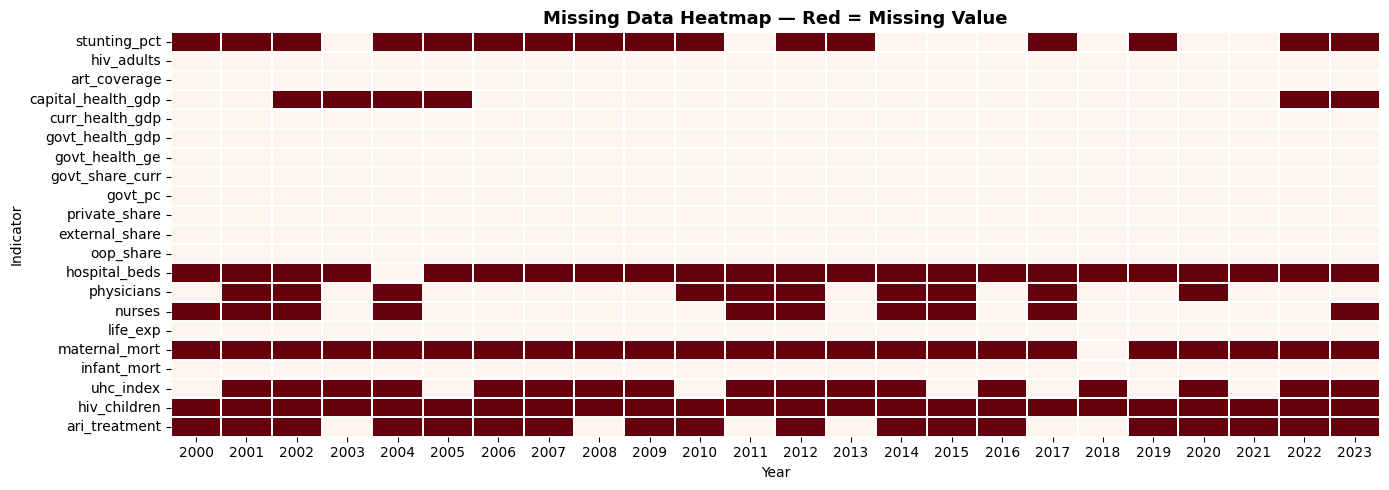

In [11]:
# Visualise missing data as a heatmap
fig, ax = plt.subplots(figsize=(14, 5))
indicator_only = df.drop(columns=['Year', 'Year Code', 'Country Name', 'Country Code'])
sns.heatmap(indicator_only.T.isnull(), cmap='Reds', cbar=False,
            xticklabels=df['Year'], ax=ax, linewidths=0.3)
ax.set_title('Missing Data Heatmap — Red = Missing Value', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Indicator', fontsize=10)
plt.tight_layout()
plt.show()

**Observation:** Several indicators (UHC index, stunting, ARI treatment) have sparse data — recorded only at survey intervals rather than annually. We will include these where available but note their limitations in the analysis.

In [12]:
# Final cleaned dataset preview
print(f'Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns')
df[['Year', 'curr_health_gdp', 'govt_health_gdp', 'govt_health_ge',
    'oop_share', 'life_exp', 'infant_mort', 'uhc_index']].head(10)

Clean dataset: 24 rows x 25 columns


,Year,curr_health_gdp,govt_health_gdp,govt_health_ge,oop_share,life_exp,infant_mort,uhc_index
0,2000,3.20,0.59,2.37,60.16,47.14,97.10,20.00
1,2001,3.19,0.86,2.78,60.75,47.55,94.60,NaN
2,2002,2.49,0.53,2.74,65.05,48.02,91.90,NaN
3,2003,5.05,0.93,4.01,72.81,48.62,89.10,NaN
4,2004,4.63,1.20,6.55,64.55,49.15,86.40,NaN
5,2005,4.47,1.14,6.41,65.97,49.54,83.70,24.00
6,2006,4.26,0.90,7.32,70.46,49.88,81.20,NaN
7,2007,3.91,0.78,4.29,70.94,50.38,79.00,NaN
8,2008,3.70,0.66,4.59,72.76,50.75,77.10,NaN
9,2009,3.58,0.57,3.69,74.47,51.08,75.40,NaN


---
## Section 4: Exploratory Data Analysis (EDA)

Before plotting thematic charts, we explore the distribution and basic statistics of key indicators.

In [13]:
# Summary statistics for core indicators
core_cols = ['curr_health_gdp', 'govt_health_gdp', 'govt_health_ge',
             'oop_share', 'life_exp', 'infant_mort', 'govt_pc']

df[core_cols].describe().round(2)

,curr_health_gdp,govt_health_gdp,govt_health_ge,oop_share,life_exp,infant_mort,govt_pc
count,24.00,24.00,24.00,24.00,24.00,24.00,24.00
mean,3.67,0.64,4.17,71.48,51.15,75.34,10.72
std,0.59,0.21,1.25,4.84,2.01,10.51,3.29
min,2.49,0.45,2.37,60.16,47.14,60.10,3.14
25%,3.31,0.50,3.43,70.81,49.79,68.30,9.91
50%,3.58,0.56,4.10,72.33,51.59,72.50,10.75
75%,4.10,0.69,4.48,74.84,52.46,81.82,13.38
max,5.05,1.20,7.32,77.39,54.46,97.10,15.28


In [14]:
# Year-on-year change in current health expenditure (% of GDP)
df['curr_health_gdp_change'] = df['curr_health_gdp'].diff()

print('Year-on-Year change in Current Health Expenditure (% of GDP):')
df[['Year', 'curr_health_gdp', 'curr_health_gdp_change']].dropna()

Year-on-Year change in Current Health Expenditure (% of GDP):


,Year,curr_health_gdp,curr_health_gdp_change
1,2001,3.19,-0.01
2,2002,2.49,-0.70
3,2003,5.05,2.56
4,2004,4.63,-0.42
5,2005,4.47,-0.17
6,2006,4.26,-0.21
7,2007,3.91,-0.35
8,2008,3.70,-0.21
9,2009,3.58,-0.12
10,2010,3.30,-0.28


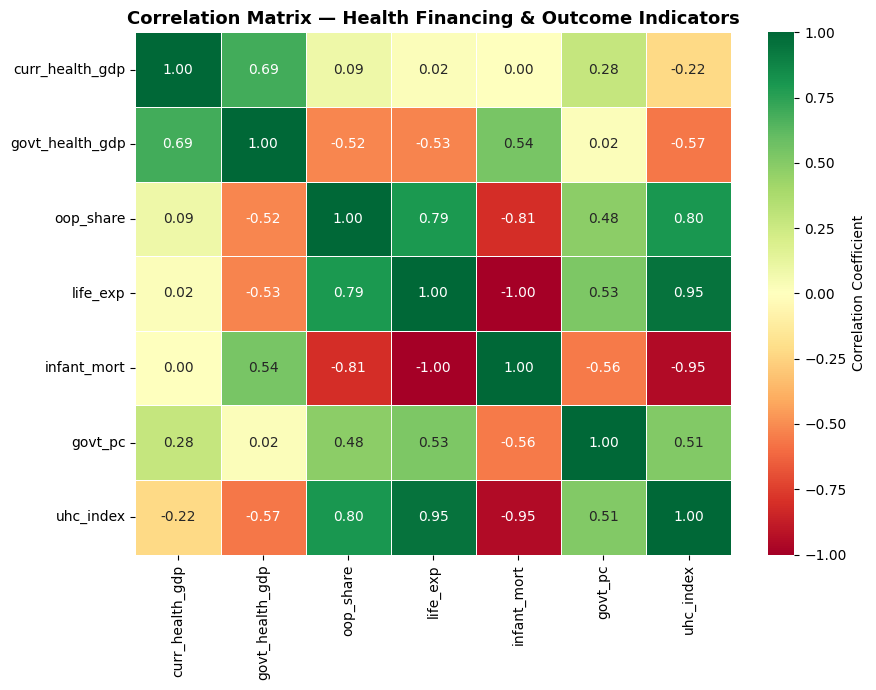

In [15]:
# Correlation matrix across key financing and outcome indicators
corr_cols = ['curr_health_gdp', 'govt_health_gdp', 'oop_share',
             'life_exp', 'infant_mort', 'govt_pc', 'uhc_index']

corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix — Health Financing & Outcome Indicators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Government per capita health spending shows a positive correlation with life expectancy and a negative correlation with infant mortality — consistent with the expectation that higher spending improves outcomes. The out-of-pocket share shows a negative correlation with life expectancy, suggesting heavier financial burden on households is associated with worse outcomes.

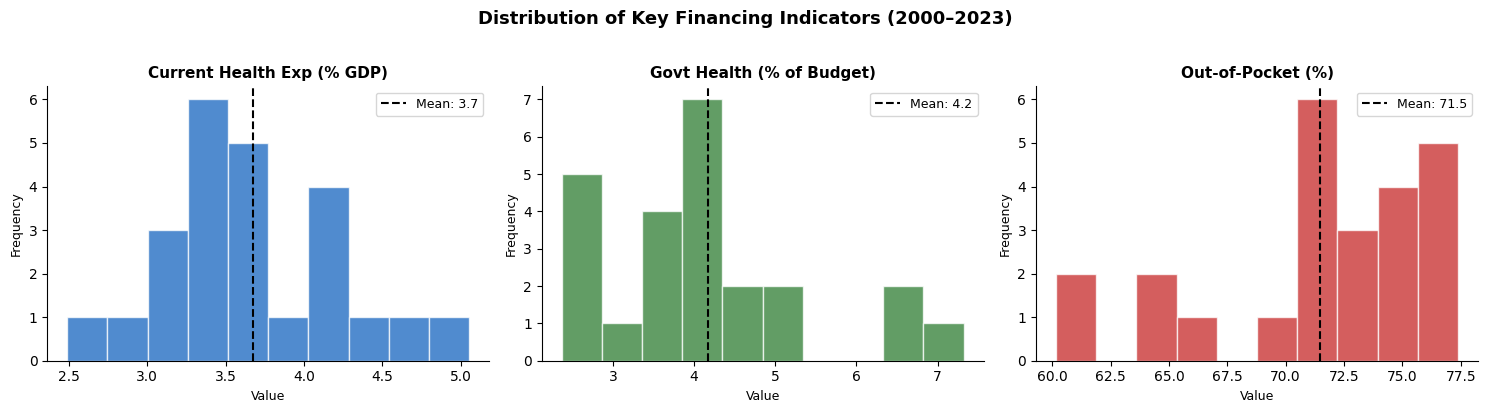

In [16]:
# Distribution plots for financing indicators
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title, color in zip(
    axes,
    ['curr_health_gdp', 'govt_health_ge', 'oop_share'],
    ['Current Health Exp (% GDP)', 'Govt Health (% of Budget)', 'Out-of-Pocket (%)'],
    ['#1565C0', '#2E7D32', '#C62828']
):
    data = df[col].dropna()
    ax.hist(data, bins=10, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(), color='black', lw=1.5, ls='--', label=f'Mean: {data.mean():.1f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Distribution of Key Financing Indicators (2000–2023)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 5: Thematic Visualisations

We now construct six thematic charts that form the core of the analysis, each addressing a specific dimension of Nigeria's health financing landscape.

In [17]:
# ── Colour palette ────────────────────────────────────────────────────────────
GREEN       = '#2E7D32'
LIGHT_GREEN = '#81C784'
RED         = '#C62828'
AMBER       = '#F9A825'
BLUE        = '#1565C0'
LIGHT_BLUE  = '#90CAF9'
GREY        = '#757575'
DARK        = '#212121'
BG          = '#FAFAFA'

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.facecolor'    : BG,
    'figure.facecolor'  : 'white',
    'axes.grid'         : True,
    'grid.color'        : '#E0E0E0',
    'grid.linewidth'    : 0.6,
})

years = df['Year']
print('Style configured.')

Style configured.


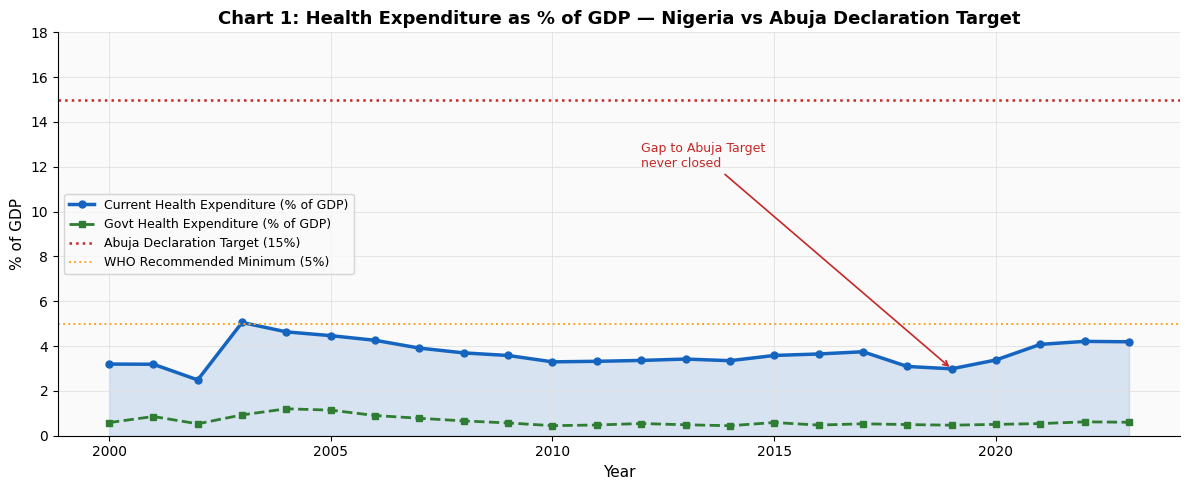


Key stat: In 2023, Nigeria's current health expenditure was 4.19% of GDP — government contribution was only 0.60%


In [18]:
# ── Chart 1: Health Expenditure as % of GDP vs Abuja Target ──────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(years, df['curr_health_gdp'], alpha=0.15, color=BLUE)
ax.plot(years, df['curr_health_gdp'], color=BLUE, lw=2.5, marker='o', ms=5,
        label='Current Health Expenditure (% of GDP)')
ax.plot(years, df['govt_health_gdp'], color=GREEN, lw=2, marker='s', ms=5, ls='--',
        label='Govt Health Expenditure (% of GDP)')
ax.axhline(15, color=RED, lw=1.8, ls=':', label='Abuja Declaration Target (15%)')
ax.axhline(5, color=AMBER, lw=1.4, ls=':', label='WHO Recommended Minimum (5%)')

ax.annotate('Gap to Abuja Target\nnever closed',
            xy=(2019, df.loc[df['Year']==2019, 'curr_health_gdp'].values[0]),
            xytext=(2012, 12), fontsize=9, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

ax.set_title('Chart 1: Health Expenditure as % of GDP — Nigeria vs Abuja Declaration Target',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of GDP', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylim(0, 18)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nKey stat: In 2023, Nigeria's current health expenditure was "
      f"{df.loc[df['Year']==2023, 'curr_health_gdp'].values[0]:.2f}% of GDP — "
      f"government contribution was only "
      f"{df.loc[df['Year']==2023, 'govt_health_gdp'].values[0]:.2f}%")

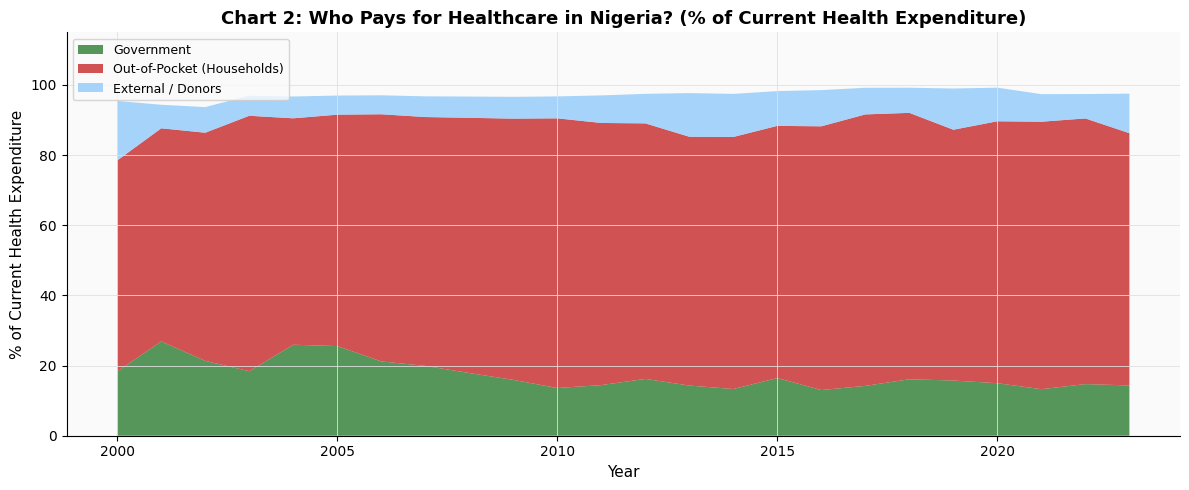


Key stat: Out-of-pocket mean across period = 71.5% of current health expenditure


In [19]:
# ── Chart 2: Funding Sources — Stacked Area ───────────────────────────────────
stack_df = df[['Year', 'govt_share_curr', 'oop_share', 'external_share']].dropna()

fig, ax = plt.subplots(figsize=(12, 5))

ax.stackplot(stack_df['Year'],
             stack_df['govt_share_curr'],
             stack_df['oop_share'],
             stack_df['external_share'],
             labels=['Government', 'Out-of-Pocket (Households)', 'External / Donors'],
             colors=[GREEN, RED, LIGHT_BLUE], alpha=0.8)

ax.set_title('Chart 2: Who Pays for Healthcare in Nigeria? (% of Current Health Expenditure)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of Current Health Expenditure', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

print(f"\nKey stat: Out-of-pocket mean across period = "
      f"{stack_df['oop_share'].mean():.1f}% of current health expenditure")

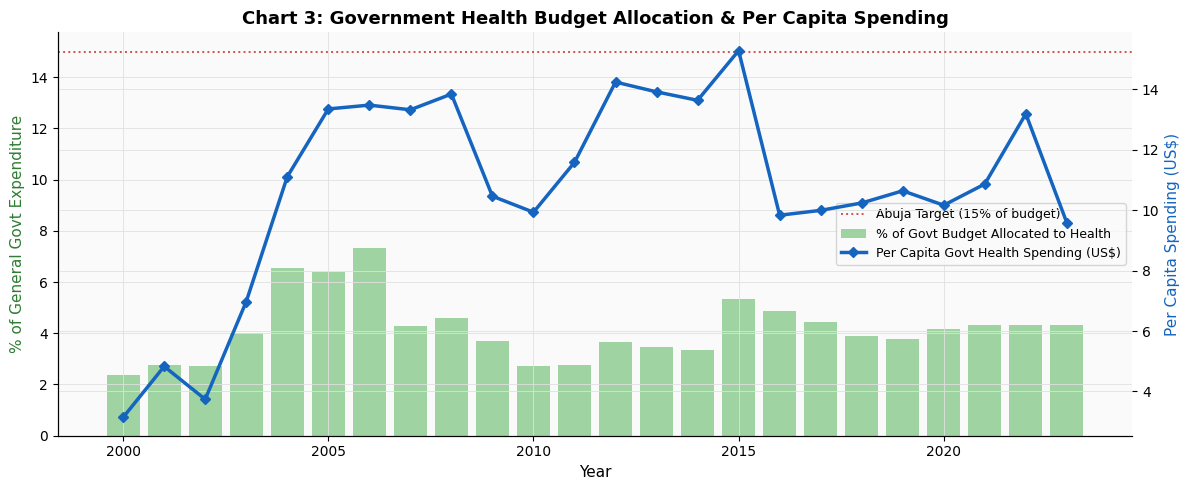

In [20]:
# ── Chart 3: Govt Budget Allocation & Per Capita Spending ────────────────────
fig, ax3 = plt.subplots(figsize=(12, 5))
ax3_twin = ax3.twinx()

ax3.bar(years, df['govt_health_ge'], color=LIGHT_GREEN, alpha=0.75,
        label='% of Govt Budget Allocated to Health')
ax3_twin.plot(years, df['govt_pc'], color=BLUE, lw=2.5,
              marker='D', ms=5, label='Per Capita Govt Health Spending (US$)')
ax3.axhline(15, color=RED, lw=1.4, ls=':', alpha=0.8, label='Abuja Target (15% of budget)')

ax3.set_title('Chart 3: Government Health Budget Allocation & Per Capita Spending',
              fontsize=13, fontweight='bold')
ax3.set_ylabel('% of General Govt Expenditure', fontsize=11, color=GREEN)
ax3_twin.set_ylabel('Per Capita Spending (US$)', fontsize=11, color=BLUE)
ax3.set_xlabel('Year', fontsize=11)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax3.spines['top'].set_visible(False)
ax3_twin.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

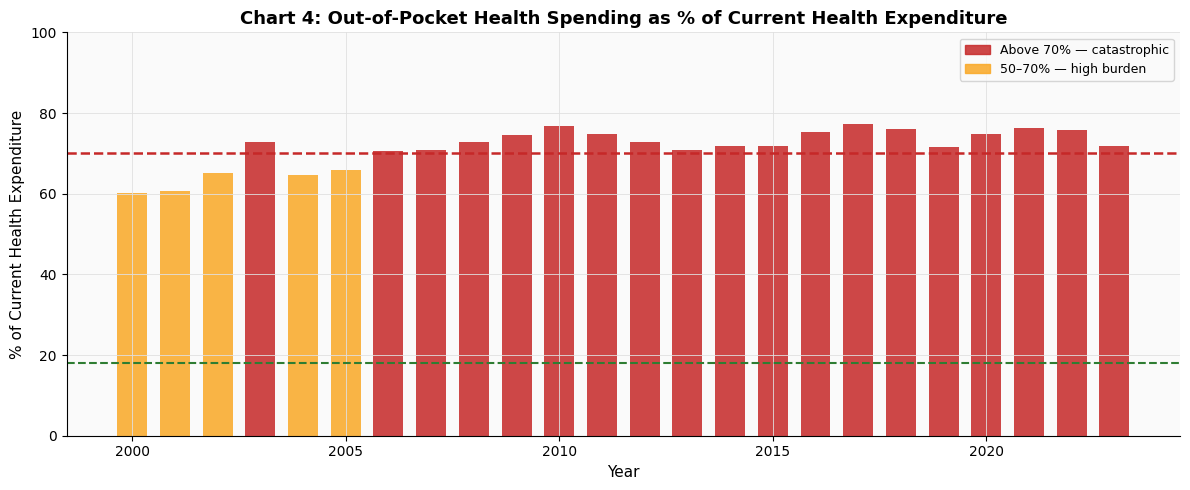


Years where OOP exceeded 70% (catastrophic level): [2003, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [21]:
# ── Chart 4: Out-of-Pocket Burden over Time ───────────────────────────────────
oop_df = df[['Year', 'oop_share']].dropna()
bar_colors = [RED if v > 70 else AMBER if v > 50 else GREEN for v in oop_df['oop_share']]

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(oop_df['Year'], oop_df['oop_share'], color=bar_colors, alpha=0.85, width=0.7)
ax.axhline(70, color=RED, lw=1.8, ls='--', label='Critical threshold (70%)')
ax.axhline(18, color=GREEN, lw=1.5, ls='--', label='WHO recommended ceiling (~15–20%)')

red_p  = mpatches.Patch(color=RED,   alpha=0.85, label='Above 70% — catastrophic')
amb_p  = mpatches.Patch(color=AMBER, alpha=0.85, label='50–70% — high burden')
ax.legend(handles=[red_p, amb_p], fontsize=9)

ax.set_title('Chart 4: Out-of-Pocket Health Spending as % of Current Health Expenditure',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of Current Health Expenditure', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

years_above_70 = oop_df[oop_df['oop_share'] > 70]['Year'].tolist()
print(f'\nYears where OOP exceeded 70% (catastrophic level): {years_above_70}')

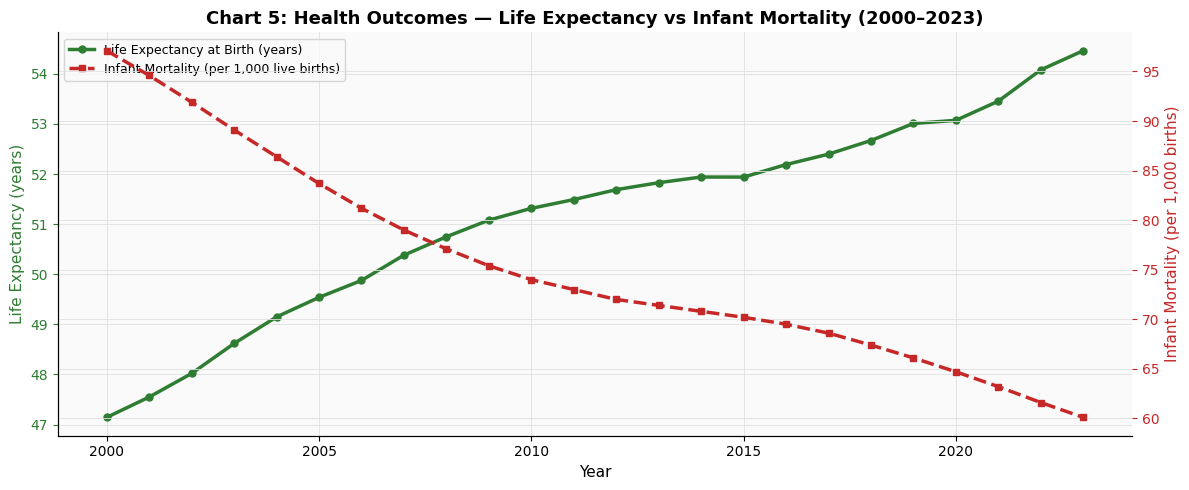

Life expectancy change 2000–2023: +7.3 years
Infant mortality change 2000–2023: -37.0 per 1,000 births


In [22]:
# ── Chart 5: Health Outcomes — Life Expectancy & Infant Mortality ─────────────
fig, ax5 = plt.subplots(figsize=(12, 5))
ax5_twin = ax5.twinx()

ax5.plot(years, df['life_exp'], color=GREEN, lw=2.5, marker='o', ms=5,
         label='Life Expectancy at Birth (years)')
ax5_twin.plot(years, df['infant_mort'], color=RED, lw=2.5, marker='s', ms=5, ls='--',
              label='Infant Mortality (per 1,000 live births)')

ax5.set_title('Chart 5: Health Outcomes — Life Expectancy vs Infant Mortality (2000–2023)',
              fontsize=13, fontweight='bold')
ax5.set_ylabel('Life Expectancy (years)', fontsize=11, color=GREEN)
ax5_twin.set_ylabel('Infant Mortality (per 1,000 births)', fontsize=11, color=RED)
ax5.set_xlabel('Year', fontsize=11)
ax5.tick_params(axis='y', colors=GREEN)
ax5_twin.tick_params(axis='y', colors=RED)

lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax5.spines['top'].set_visible(False)
ax5_twin.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

life_change = df['life_exp'].iloc[-1] - df['life_exp'].iloc[0]
inf_change  = df['infant_mort'].iloc[-1] - df['infant_mort'].iloc[0]
print(f'Life expectancy change 2000–2023: +{life_change:.1f} years')
print(f'Infant mortality change 2000–2023: {inf_change:.1f} per 1,000 births')

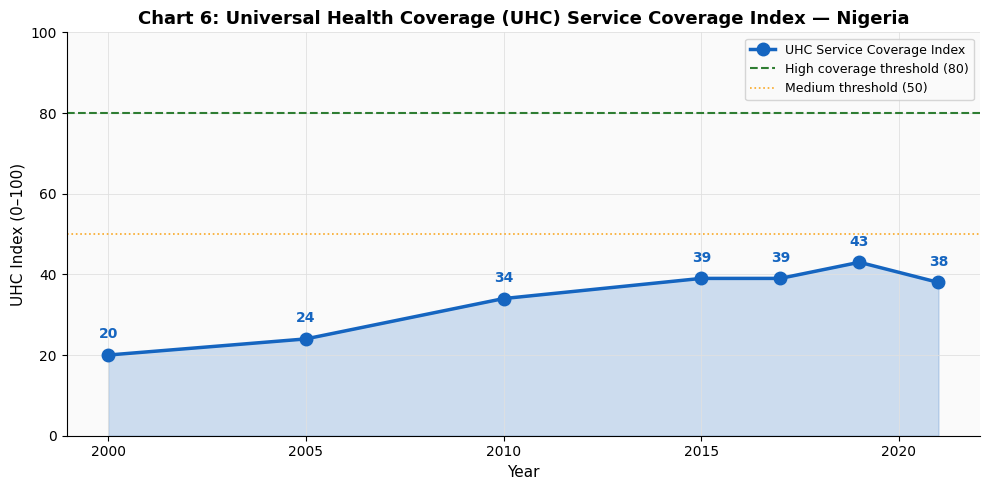


UHC Index in 2021: 38.0
Interpretation: A score of 38–43 means Nigeria provides adequate coverage to less than half its population.


In [23]:
# ── Chart 6: Universal Health Coverage (UHC) Index ───────────────────────────
uhc_df = df[['Year', 'uhc_index']].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(uhc_df['Year'], uhc_df['uhc_index'], alpha=0.2, color=BLUE)
ax.plot(uhc_df['Year'], uhc_df['uhc_index'], color=BLUE, lw=2.5,
        marker='o', ms=9, label='UHC Service Coverage Index')

for _, row in uhc_df.iterrows():
    ax.annotate(f"{int(row['uhc_index'])}",
                (row['Year'], row['uhc_index']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold', color=BLUE)

ax.axhline(80, color=GREEN, lw=1.5, ls='--', label='High coverage threshold (80)')
ax.axhline(50, color=AMBER, lw=1.2, ls=':',  label='Medium threshold (50)')

ax.set_title('Chart 6: Universal Health Coverage (UHC) Service Coverage Index — Nigeria',
             fontsize=13, fontweight='bold')
ax.set_ylabel('UHC Index (0–100)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nUHC Index in 2021: {uhc_df[uhc_df['Year']==2021]['uhc_index'].values[0]}")
print('Interpretation: A score of 38–43 means Nigeria provides adequate coverage to less than half its population.')

---
## Section 6: Combined Dashboard

All six charts are combined into a single publication-ready dashboard figure.

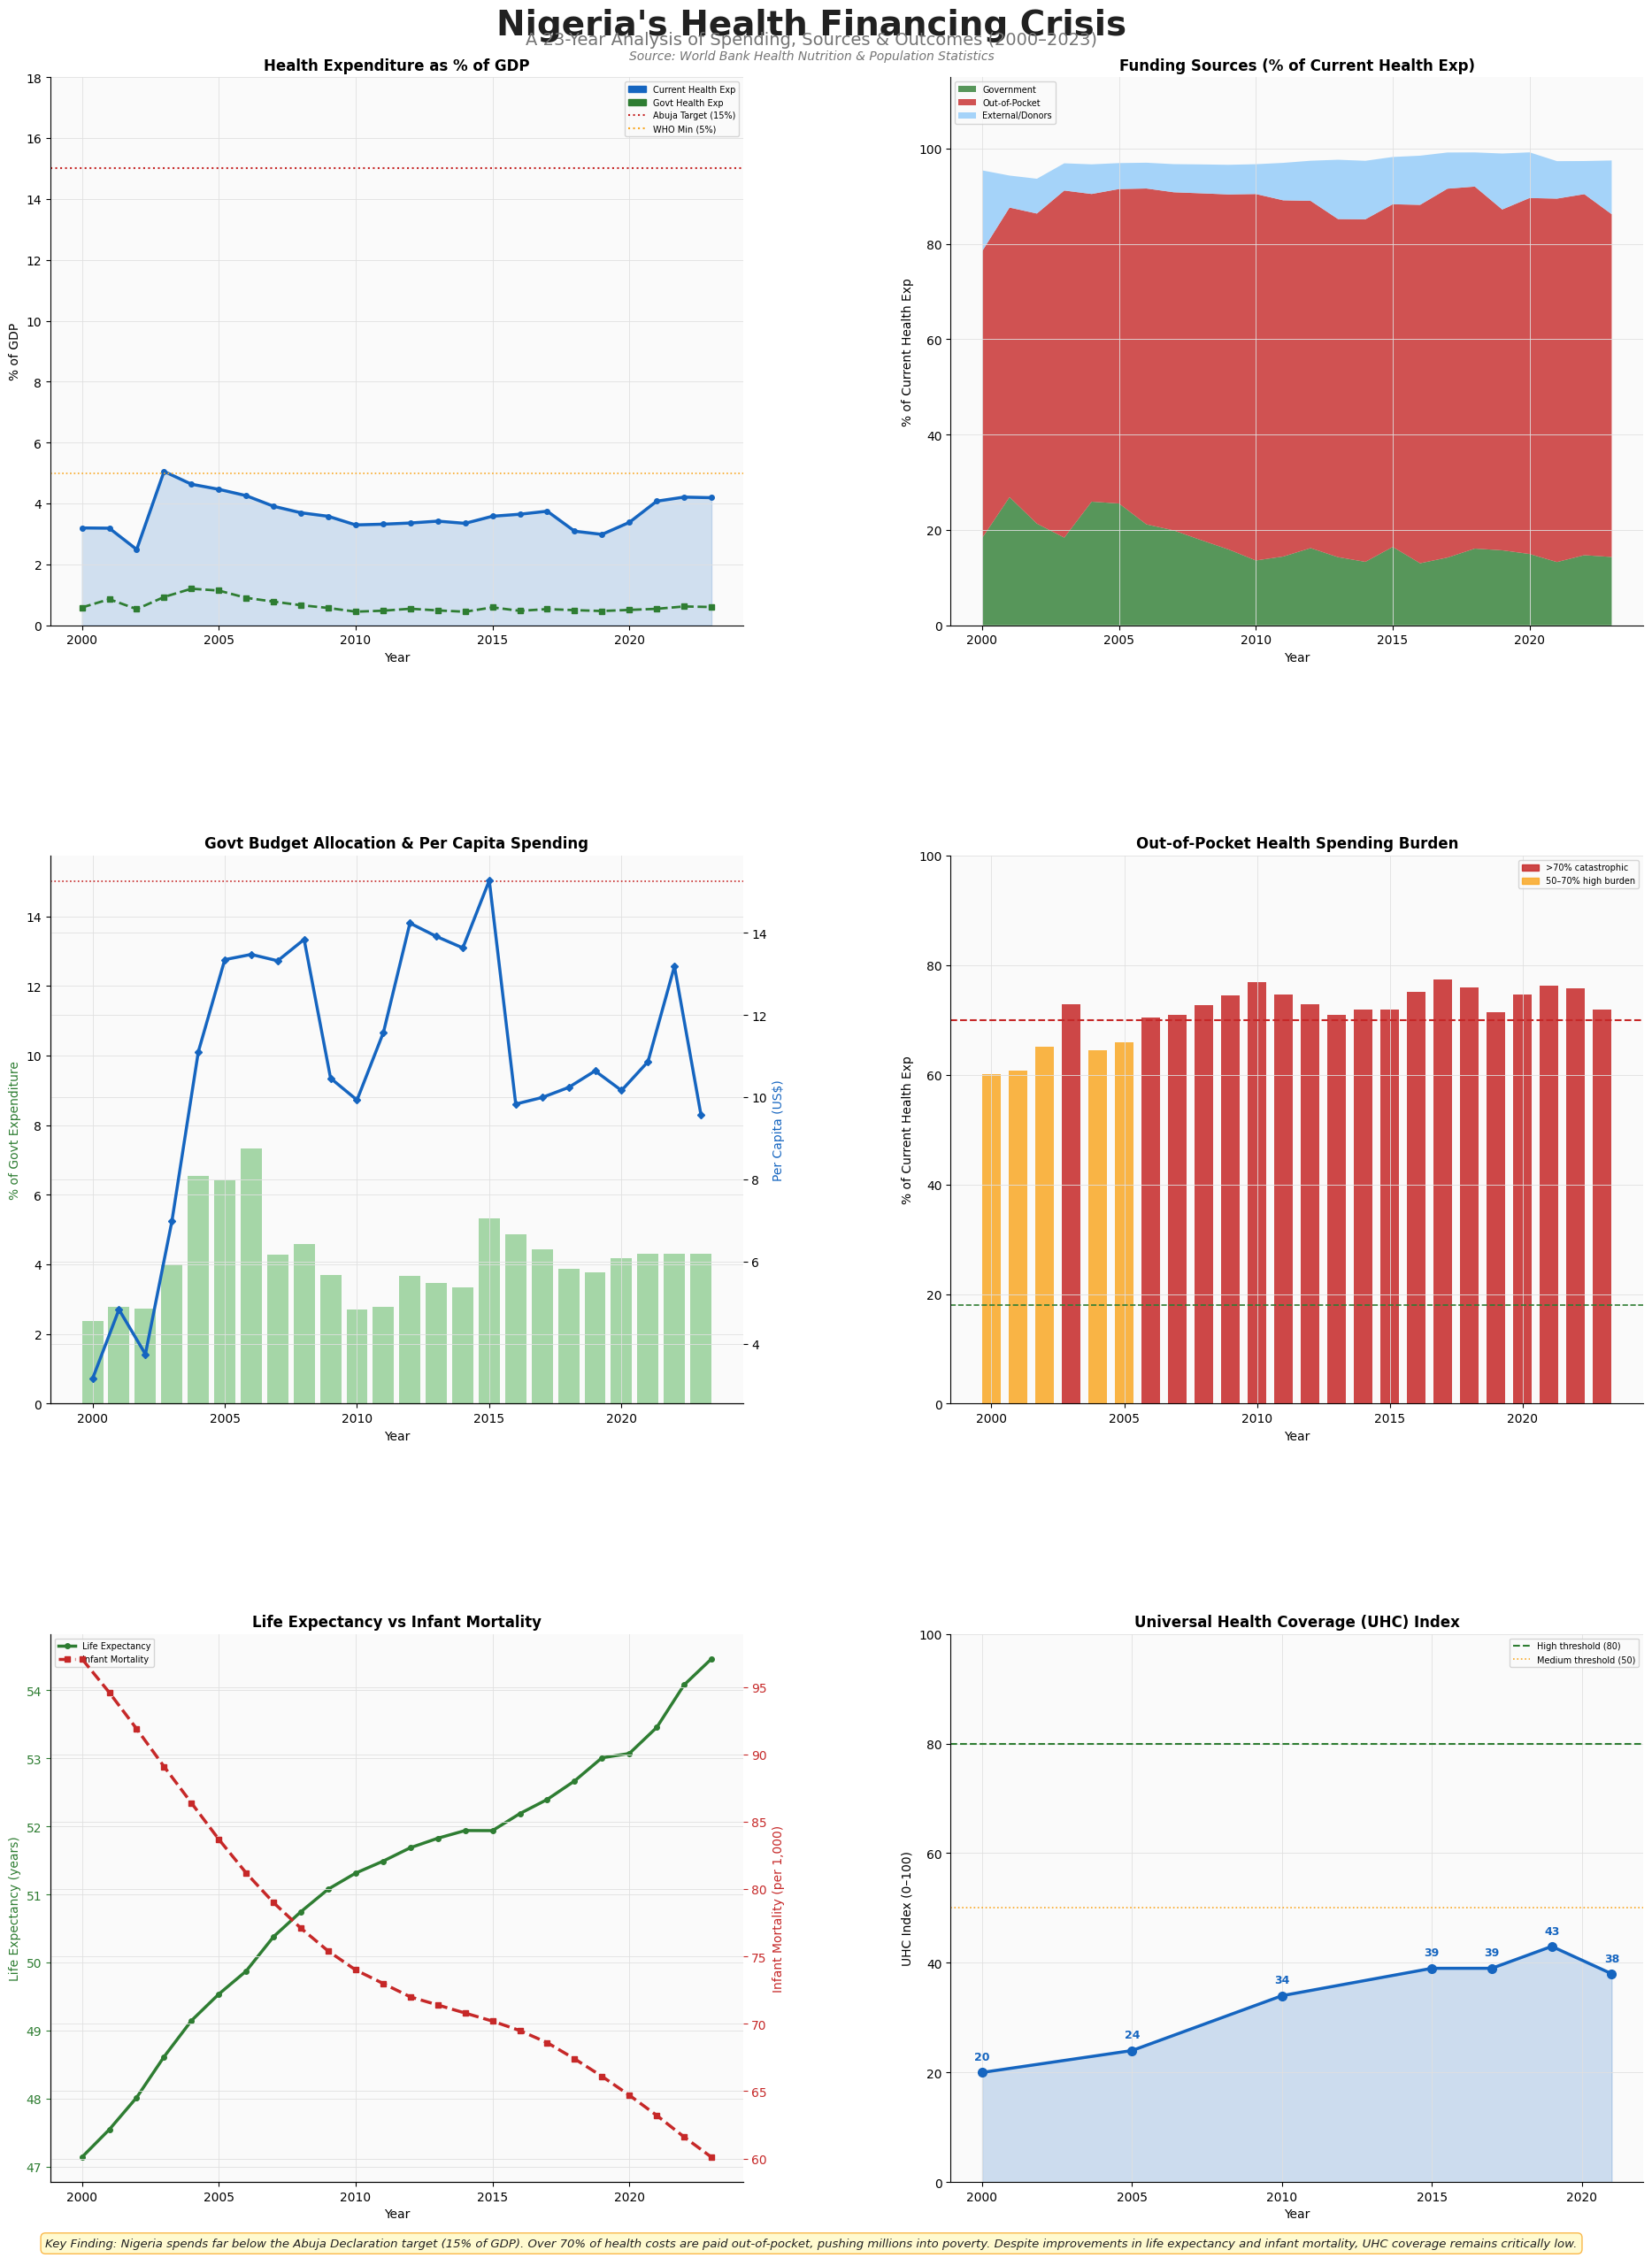

Dashboard saved.


In [24]:
fig = plt.figure(figsize=(20, 26))
fig.patch.set_facecolor('white')

fig.text(0.5, 0.985, "Nigeria's Health Financing Crisis",
         ha='center', va='top', fontsize=28, fontweight='bold', color=DARK)
fig.text(0.5, 0.975, "A 23-Year Analysis of Spending, Sources & Outcomes (2000–2023)",
         ha='center', va='top', fontsize=14, color=GREY)
fig.text(0.5, 0.967, "Source: World Bank Health Nutrition & Population Statistics",
         ha='center', va='top', fontsize=10, color=GREY, style='italic')

gs = GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.3,
              top=0.955, bottom=0.04, left=0.07, right=0.97)

# Chart 1
ax1 = fig.add_subplot(gs[0, 0])
ax1.fill_between(years, df['curr_health_gdp'], alpha=0.18, color=BLUE)
ax1.plot(years, df['curr_health_gdp'], color=BLUE, lw=2.5, marker='o', ms=4)
ax1.plot(years, df['govt_health_gdp'], color=GREEN, lw=2, marker='s', ms=4, ls='--')
ax1.axhline(15, color=RED, lw=1.5, ls=':')
ax1.axhline(5,  color=AMBER, lw=1.2, ls=':')
ax1.set_title('Health Expenditure as % of GDP', fontsize=12, fontweight='bold')
ax1.set_ylabel('% of GDP'); ax1.set_xlabel('Year'); ax1.set_ylim(0, 18)
p1 = [mpatches.Patch(color=BLUE, label='Current Health Exp'),
      mpatches.Patch(color=GREEN, label='Govt Health Exp'),
      plt.Line2D([0],[0], color=RED, ls=':', label='Abuja Target (15%)'),
      plt.Line2D([0],[0], color=AMBER, ls=':', label='WHO Min (5%)')]
ax1.legend(handles=p1, fontsize=7)

# Chart 2
ax2 = fig.add_subplot(gs[0, 1])
stack_df = df[['Year','govt_share_curr','oop_share','external_share']].dropna()
ax2.stackplot(stack_df['Year'], stack_df['govt_share_curr'],
              stack_df['oop_share'], stack_df['external_share'],
              labels=['Government','Out-of-Pocket','External/Donors'],
              colors=[GREEN, RED, LIGHT_BLUE], alpha=0.8)
ax2.set_title('Funding Sources (% of Current Health Exp)', fontsize=12, fontweight='bold')
ax2.set_ylabel('% of Current Health Exp'); ax2.set_xlabel('Year'); ax2.set_ylim(0, 115)
ax2.legend(fontsize=7, loc='upper left')

# Chart 3
ax3 = fig.add_subplot(gs[1, 0])
ax3t = ax3.twinx()
ax3.bar(years, df['govt_health_ge'], color=LIGHT_GREEN, alpha=0.7)
ax3t.plot(years, df['govt_pc'], color=BLUE, lw=2.5, marker='D', ms=4)
ax3.axhline(15, color=RED, lw=1.2, ls=':')
ax3.set_title('Govt Budget Allocation & Per Capita Spending', fontsize=12, fontweight='bold')
ax3.set_ylabel('% of Govt Expenditure', color=GREEN); ax3t.set_ylabel('Per Capita (US$)', color=BLUE)
ax3.set_xlabel('Year')
ax3.spines['top'].set_visible(False); ax3t.spines['top'].set_visible(False)

# Chart 4
ax4 = fig.add_subplot(gs[1, 1])
oop_df = df[['Year','oop_share']].dropna()
bar_colors = [RED if v > 70 else AMBER if v > 50 else GREEN for v in oop_df['oop_share']]
ax4.bar(oop_df['Year'], oop_df['oop_share'], color=bar_colors, alpha=0.85, width=0.7)
ax4.axhline(70, color=RED, lw=1.5, ls='--'); ax4.axhline(18, color=GREEN, lw=1.2, ls='--')
ax4.set_title('Out-of-Pocket Health Spending Burden', fontsize=12, fontweight='bold')
ax4.set_ylabel('% of Current Health Exp'); ax4.set_xlabel('Year'); ax4.set_ylim(0, 100)
r_p = mpatches.Patch(color=RED, alpha=0.85, label='>70% catastrophic')
a_p = mpatches.Patch(color=AMBER, alpha=0.85, label='50–70% high burden')
ax4.legend(handles=[r_p, a_p], fontsize=7)

# Chart 5
ax5 = fig.add_subplot(gs[2, 0])
ax5t = ax5.twinx()
ax5.plot(years, df['life_exp'], color=GREEN, lw=2.5, marker='o', ms=4, label='Life Expectancy')
ax5t.plot(years, df['infant_mort'], color=RED, lw=2.5, marker='s', ms=4, ls='--', label='Infant Mortality')
ax5.set_title('Life Expectancy vs Infant Mortality', fontsize=12, fontweight='bold')
ax5.set_ylabel('Life Expectancy (years)', color=GREEN); ax5t.set_ylabel('Infant Mortality (per 1,000)', color=RED)
ax5.set_xlabel('Year')
ax5.tick_params(axis='y', colors=GREEN); ax5t.tick_params(axis='y', colors=RED)
ax5.spines['top'].set_visible(False); ax5t.spines['top'].set_visible(False)
l1,lb1=ax5.get_legend_handles_labels(); l2,lb2=ax5t.get_legend_handles_labels()
ax5.legend(l1+l2, lb1+lb2, fontsize=7)

# Chart 6
ax6 = fig.add_subplot(gs[2, 1])
uhc_df = df[['Year','uhc_index']].dropna()
ax6.fill_between(uhc_df['Year'], uhc_df['uhc_index'], alpha=0.2, color=BLUE)
ax6.plot(uhc_df['Year'], uhc_df['uhc_index'], color=BLUE, lw=2.5, marker='o', ms=7)
for _, row in uhc_df.iterrows():
    ax6.annotate(f"{int(row['uhc_index'])}", (row['Year'], row['uhc_index']),
                 textcoords='offset points', xytext=(0,10), ha='center', fontsize=9,
                 fontweight='bold', color=BLUE)
ax6.axhline(80, color=GREEN, lw=1.5, ls='--', label='High threshold (80)')
ax6.axhline(50, color=AMBER, lw=1.2, ls=':',  label='Medium threshold (50)')
ax6.set_title('Universal Health Coverage (UHC) Index', fontsize=12, fontweight='bold')
ax6.set_ylabel('UHC Index (0–100)'); ax6.set_xlabel('Year'); ax6.set_ylim(0, 100)
ax6.legend(fontsize=7)

fig.text(0.5, 0.012,
    "Key Finding: Nigeria spends far below the Abuja Declaration target (15% of GDP). Over 70% of health costs "
    "are paid out-of-pocket, pushing millions into poverty. Despite improvements in life expectancy and infant "
    "mortality, UHC coverage remains critically low.",
    ha='center', fontsize=9.5, color=DARK, style='italic',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', edgecolor=AMBER, alpha=0.8))

plt.savefig('nigeria_health_financing_dashboard.png', dpi=180, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

---
## Section 7: Key Findings & Policy Implications

### Finding 1: Nigeria Has Never Met the Abuja Declaration Target
In 2001, African Union member states signed the Abuja Declaration, committing to allocate **at least 15% of national budgets to health**. Over 23 years, Nigeria's government health spending has never exceeded **7.3% of general government expenditure** (2006). By 2023, it stood at just **4.3%** — less than a third of the commitment.

### Finding 2: Citizens Bear an Unsustainable Financial Burden
Out-of-pocket payments have consistently funded **60–77% of all health spending**, exceeding the WHO's critical threshold of 70% in multiple years. This means most Nigerians pay for healthcare directly from their pockets with little to no insurance or government subsidy — a leading driver of medical impoverishment.

### Finding 3: Government Per Capita Spending Has Been Volatile and Insufficient
Government health spending per capita peaked in the mid-2000s during the oil boom but has since been erratic, reflecting Nigeria's vulnerability to oil price fluctuations. This makes health financing unpredictable and undermines long-term planning.

### Finding 4: Outcomes Are Improving But Too Slowly
Life expectancy improved from **47.1 years (2000) to 54.5 years (2023)** and infant mortality fell from **97.1 to 60.1 per 1,000 live births**. While positive, these improvements fall short of what commensurate public investment should have produced.

### Finding 5: UHC Coverage Remains Critically Low
Nigeria's UHC service coverage index of **38–43** (out of 100) indicates that a majority of the population still lacks access to essential health services. The country is far from achieving SDG 3.8 on universal health coverage by 2030.

---

### Policy Recommendations
1. **Honour the Abuja Commitment** — Progressively increase the health budget share toward the 15% target, with annual accountability reporting.
2. **Expand the National Health Insurance Scheme (NHIS)** — Reduce reliance on out-of-pocket payments by scaling up pre-payment and pooling mechanisms.
3. **De-link Health Financing from Oil Revenue** — Establish a dedicated health stabilisation fund to protect budgets during commodity downturns.
4. **Invest in Primary Healthcare** — Redirect resources toward preventive and primary care which delivers the highest returns on investment for maternal and child health outcomes.
5. **Strengthen Health Data Systems** — Several key indicators (stunting, ARI treatment, UHC) had sparse annual data, limiting analysis. Robust routine data collection is itself a governance priority.

In [25]:
# Final summary table
summary = pd.DataFrame({
    'Indicator': [
        'Current Health Expenditure (% of GDP)',
        'Govt Health Expenditure (% of GDP)',
        'Govt Health (% of Govt Budget)',
        'Out-of-Pocket (% of Health Exp)',
        'Life Expectancy (years)',
        'Infant Mortality (per 1,000)',
        'UHC Index (0–100)',
    ],
    '2000': [
        f"{df.loc[df['Year']==2000, 'curr_health_gdp'].values[0]:.2f}",
        f"{df.loc[df['Year']==2000, 'govt_health_gdp'].values[0]:.2f}",
        f"{df.loc[df['Year']==2000, 'govt_health_ge'].values[0]:.2f}",
        f"{df.loc[df['Year']==2000, 'oop_share'].values[0]:.2f}",
        f"{df.loc[df['Year']==2000, 'life_exp'].values[0]:.1f}",
        f"{df.loc[df['Year']==2000, 'infant_mort'].values[0]:.1f}",
        '20',
    ],
    '2023': [
        f"{df.loc[df['Year']==2023, 'curr_health_gdp'].values[0]:.2f}",
        f"{df.loc[df['Year']==2023, 'govt_health_gdp'].values[0]:.2f}",
        f"{df.loc[df['Year']==2023, 'govt_health_ge'].values[0]:.2f}",
        f"{df.loc[df['Year']==2023, 'oop_share'].values[0]:.2f}",
        f"{df.loc[df['Year']==2023, 'life_exp'].values[0]:.1f}",
        f"{df.loc[df['Year']==2023, 'infant_mort'].values[0]:.1f}",
        '43 (2019)',
    ],
    'Direction': ['→','→','↑','↓ slightly','↑','↑ (improving)','↑']
})

print('=== Summary: Nigeria Health Financing — 2000 vs 2023 ===')
summary

=== Summary: Nigeria Health Financing — 2000 vs 2023 ===


,Indicator,2000,2023,Direction
0,Current Health Expenditure (% of GDP),3.20,4.19,→
1,Govt Health Expenditure (% of GDP),0.59,0.60,→
2,Govt Health (% of Govt Budget),2.37,4.31,↑
3,Out-of-Pocket (% of Health Exp),60.16,71.90,↓ slightly
4,Life Expectancy (years),47.1,54.5,↑
5,"Infant Mortality (per 1,000)",97.1,60.1,↑ (improving)
6,UHC Index (0–100),20,43 (2019),↑
